<a href="https://colab.research.google.com/github/korzhimanov/dsp-seminars/blob/main/seminars/4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическое занятие №4

## Случайные сигналы, шумы и спектральная плотность мощности

## Задание 1. Генерация белого, розового и красного шума
Сгенерируйте три сигнала длительностью 2 секунды с частотой дискретизации 1000 Гц:
- Белый гауссов шум с нулевым средним и дисперсией 1.
- Розовый шум – возьмите Фурье-преобразование от белого шума, домножьте его на функцию $1/\sqrt{f}$ и возьмите обратное Фурье-преобразование, результат нормализуйте.
- красный шум – кумулятивная сумма белого шума (нормалиованная).

Постройте временные графики всех трёх сигналов. Вычислите и выведите их средние значения и дисперсии.


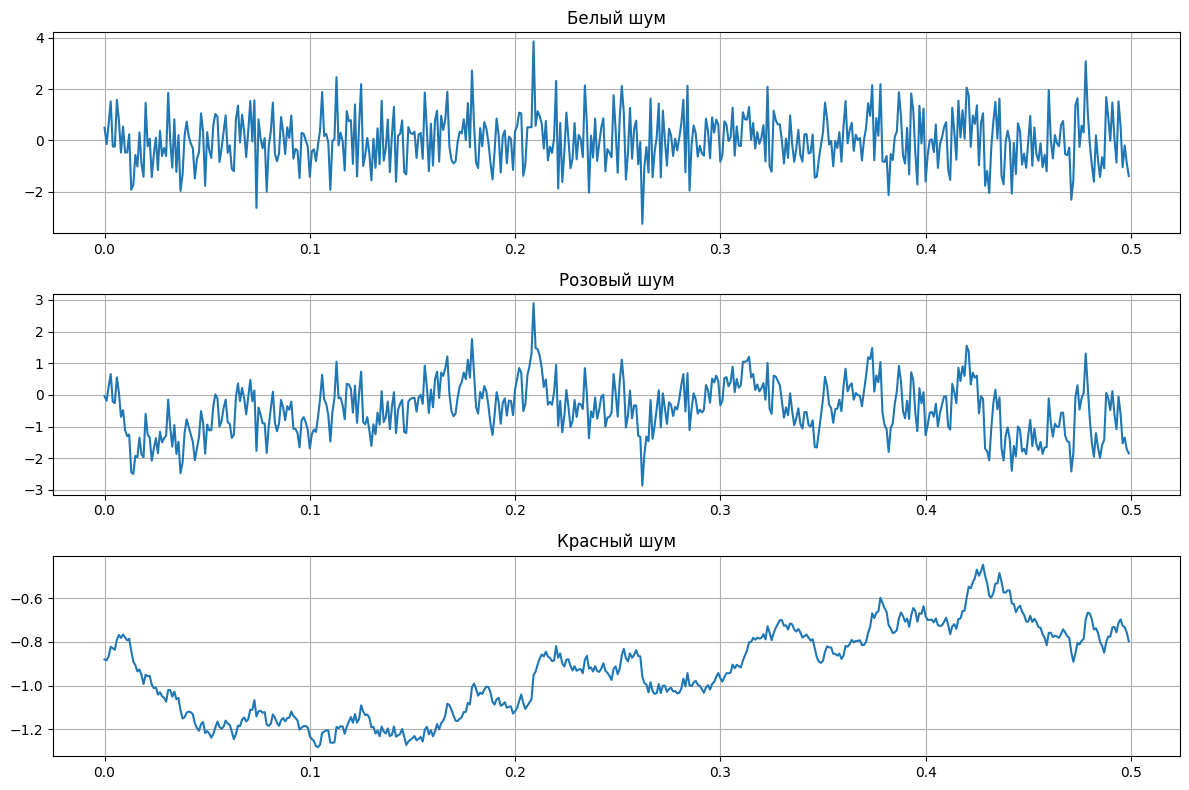

Белый шум: mean = 0.0451, var = 0.9766
Розовый шум: mean = 0.0000, var = 1.0000
Красный шум: mean = 0.0000, var = 1.0000


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)

np.random.seed(42)

fs = 1000
duration = 2
N = fs * duration
t = np.arange(N) / fs


def make_white(var=1.0, size=N):
    return np.random.normal(0, np.sqrt(var), size)


def make_pink_from_white(white, var=1.0):
    X = np.fft.rfft(white)
    freqs = np.fft.rfftfreq(len(white), d=1 / fs)
    scale = np.zeros_like(freqs)
    scale[1:] = 1 / np.sqrt(freqs[1:])

    pink = np.fft.irfft(X * scale, n=len(white))
    pink = pink - np.mean(pink)
    pink = pink / np.std(pink)
    return pink * np.sqrt(var)


def make_red_from_white(white, var=1.0):
    red = np.cumsum(white)
    red = red - np.mean(red)
    red = red / np.std(red)
    return red * np.sqrt(var)


white_noise = make_white()
pink_noise = make_pink_from_white(white_noise)
red_noise = make_red_from_white(white_noise)

noises = {
    'Белый шум': white_noise,
    'Розовый шум': pink_noise,
    'Красный шум': red_noise,
}

plt.figure(figsize=(12, 8))
for i, (name, x) in enumerate(noises.items(), start=1):
    plt.subplot(3, 1, i)
    plt.plot(t[:500], x[:500])
    plt.title(name)
    plt.grid(True)

plt.tight_layout()
plt.show()

for name, x in noises.items():
    print(f'{name}: mean = {np.mean(x):.4f}, var = {np.var(x):.4f}')



**Вопрос:** Как визуально отличаются разные виды шума? Совпадают ли вычисленные средние и дисперсии сигналов от теоретических? Если отличаются, объясните почему.


Белый шум выглядит самым резким и хаотичным, розовый более плавным, а красный самым медленным и сглаженным. Средние близки к нулю, а дисперсии близки к теоретическим. Небольшие отличия возникают из-за конечной длины реализации


## Задание 2. Вычисление автокорреляционной функции (АКФ)
Для каждого из сгенерированных шумов вычислите автокорреляционную функцию (с помощью `np.correlate(x, x, mode='full')`). Возьмите только положительные сдвиги (или сдвиги от -N+1 до N-1, но визуализируйте симметричную часть). Постройте графики нормированных АКФ (поделите на значение при нулевом сдвиге) для всех трёх шумов на одном рисунке.


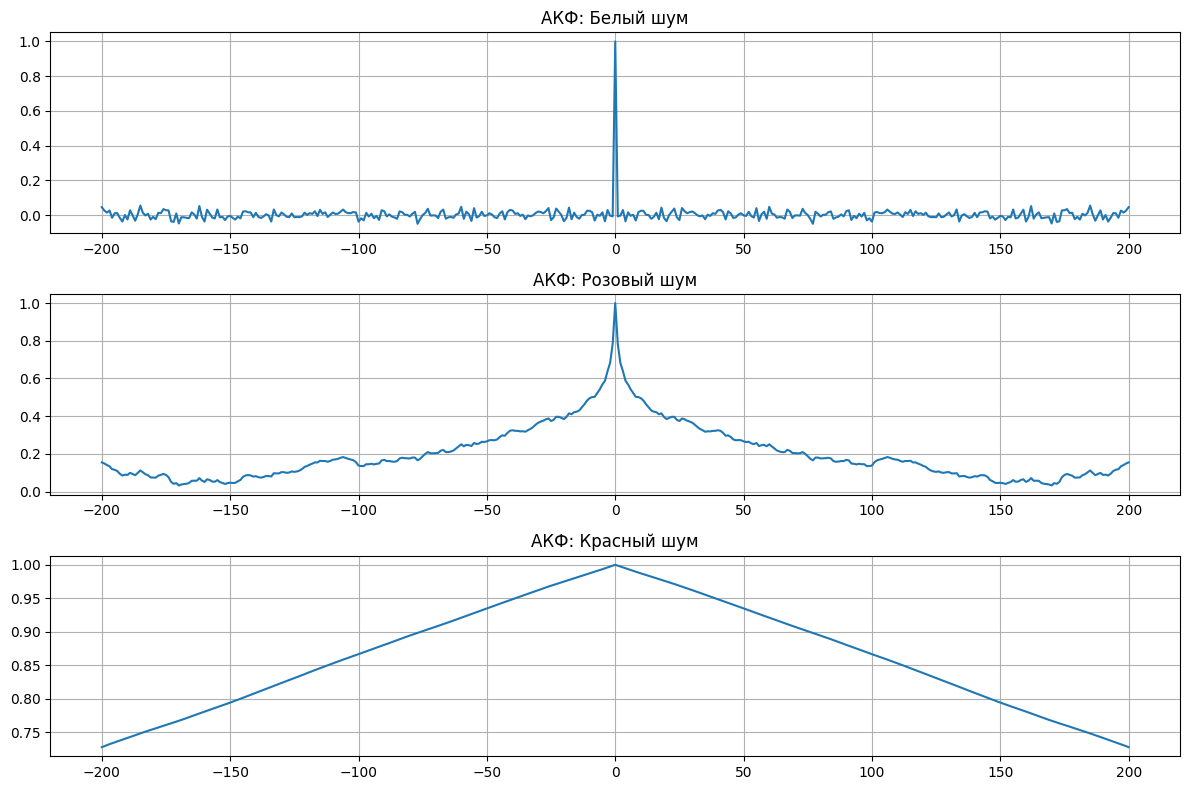

In [2]:
def autocorr(x):
    acf = np.correlate(x, x, mode='full')
    acf = acf / np.max(acf)
    lags = np.arange(-len(x) + 1, len(x))
    return lags, acf

plt.figure(figsize=(12, 8))
for i, (name, x) in enumerate(noises.items(), start=1):
    lags, acf = autocorr(x)
    center = len(acf) // 2

    plt.subplot(3, 1, i)
    plt.plot(lags[center-200:center+201], acf[center-200:center+201])
    plt.title(f'АКФ: {name}')
    plt.grid(True)

plt.tight_layout()
plt.show()



**Вопрос:** Сравнив АКФ и временную развёртку для разных видов шума, сделайте вывод о том, как форма АКФ связана с гладкостью сигнала.


Чем более гладкий сигнал во времени, тем медленнее спадает его АКФ. У белого шума АКФ почти нулевая вне нулевого лага, у розового она шире, а у красного самая широкая


## Задание 3. Оценка спектральной плотности мощности (СПМ). Периодограмма и метод Уэлча
Для каждого типа шума вычислите:
- Периодограмму с помощью `scipy.signal.periodogram`.
- Оценку СПМ методом Уэлча с помощью `scipy.signal.welch` с параметрами `nperseg=256`, `noverlap=128`, окно Ханна.

Постройте на одном графике (для каждого шума отдельно) периодограмму и оценку Уэлча в двойном логарифмическом масштабе по оси Y (используйте `plt.loglog`).


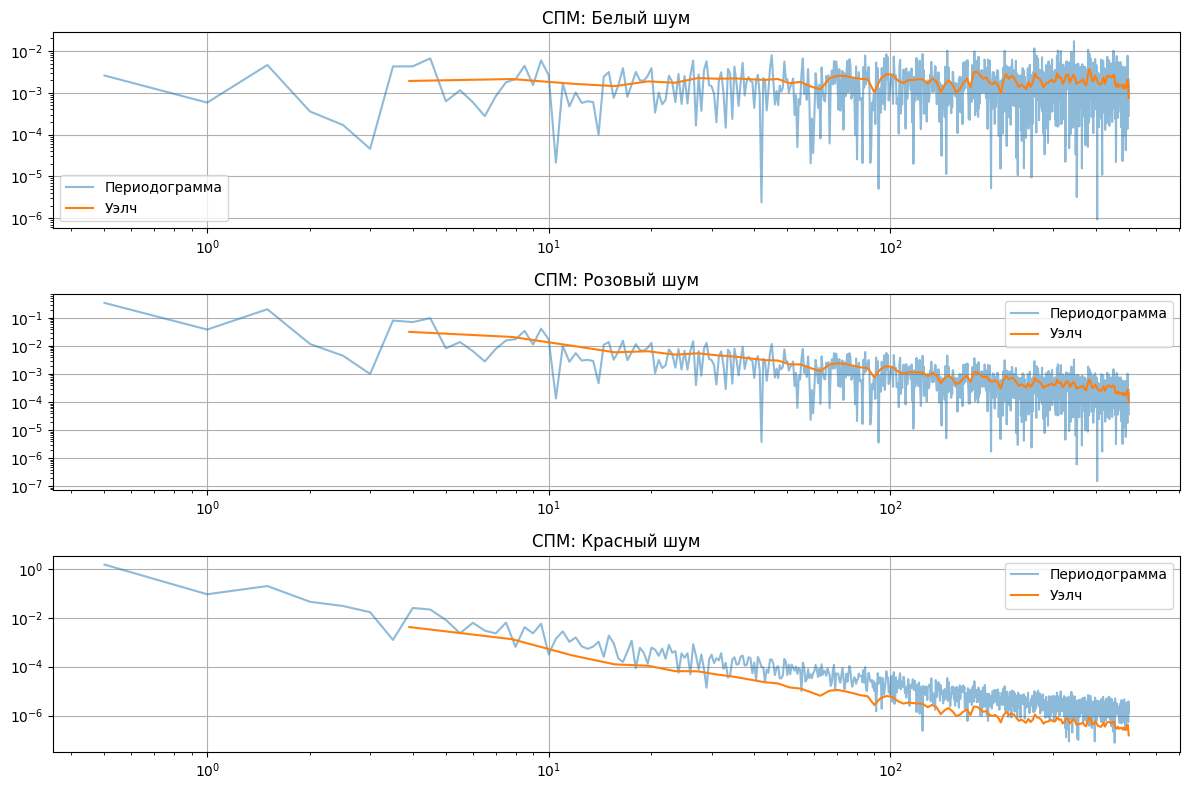

In [3]:
plt.figure(figsize=(12, 8))
for i, (name, x) in enumerate(noises.items(), start=1):
    f_per, P_per = signal.periodogram(x, fs)
    f_welch, P_welch = signal.welch(x, fs, nperseg=256, noverlap=128, window='hann')

    plt.subplot(3, 1, i)
    plt.loglog(f_per[1:], P_per[1:], alpha=0.5, label='Периодограмма')
    plt.loglog(f_welch[1:], P_welch[1:], label='Уэлч')
    plt.title(f'СПМ: {name}')
    plt.grid(True)
    plt.legend()

plt.tight_layout()
plt.show()



**Вопрос:** Как выглядят зависимости СПМ от частоты у разных видов шума в двойном логарифмическом масштабе? Как они должны выглядеть теоретически?


1) У белого шума СПМ почти горизонтальна
2) У розового она убывает примерно как 1/f, поэтому в двойном логарифмическом масштабе получается наклон около -1
3) У красного она убывает примерно как 1/f^2, поэтому наклон ближе к -2


## Задание 4. Влияние длины сегмента в методе Уэлча
Для белого шума вычислите оценку СПМ методом Уэлча с разной длиной сегмента: `nperseg = 64, 128, 256, 512`. Используйте окно Ханна, перекрытие 50%. Постройте все четыре оценки на одном графике (логарифмическая шкала по Y).


nperseg = 64, df = 15.6250 Гц
nperseg = 128, df = 7.8125 Гц
nperseg = 256, df = 3.9062 Гц
nperseg = 512, df = 1.9531 Гц


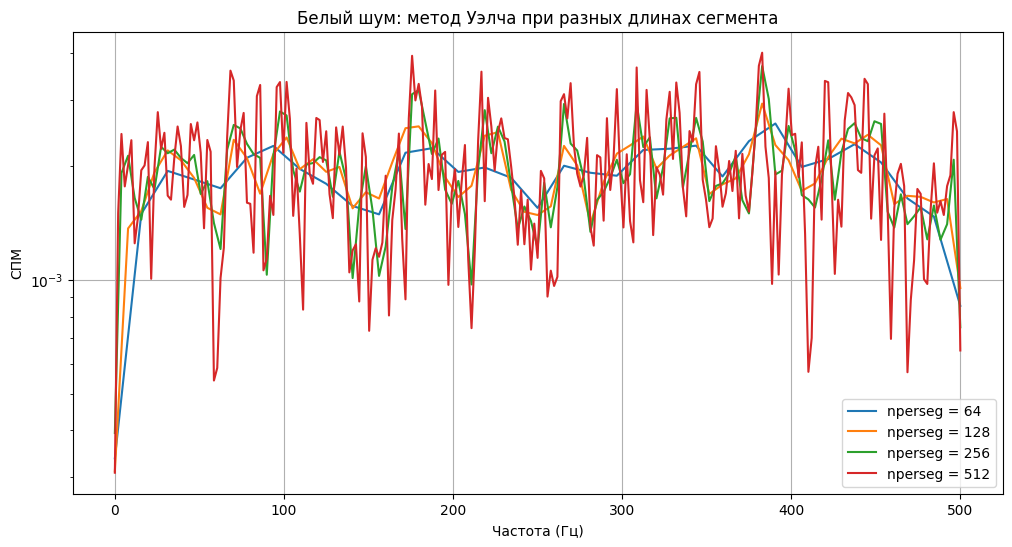

In [4]:
nperseg_values = [64, 128, 256, 512]

plt.figure(figsize=(12, 6))
for nperseg in nperseg_values:
    f_welch, P_welch = signal.welch(
        white_noise,
        fs,
        nperseg=nperseg,
        noverlap=nperseg // 2,
        window='hann'
    )
    plt.semilogy(f_welch, P_welch, label=f'nperseg = {nperseg}')
    print(f'nperseg = {nperseg}, df = {f_welch[1] - f_welch[0]:.4f} Гц')

plt.title('Белый шум: метод Уэлча при разных длинах сегмента')
plt.xlabel('Частота (Гц)')
plt.ylabel('СПМ')
plt.grid(True)
plt.legend()
plt.show()



**Вопрос:** Как увеличение длины сегмента влияет на разрешение по частоте (ширину пиков) и гладкость оценки (дисперсию значений)?


При увеличении длины сегмента частотное разрешение улучшается, потому что шаг по частоте уменьшается. Но оценка становится менее гладкой и более шумной, потому что сегментов для усреднения меньше


## Задание 5. Влияние дисперсии шума на его характеристики
Для каждого вида шума вычислите и выведите на один график при разных значениях дисперсии (например, 0.1, 1, 10):
1. Временную реализацию.
2. АКФ.
3. СПМ.

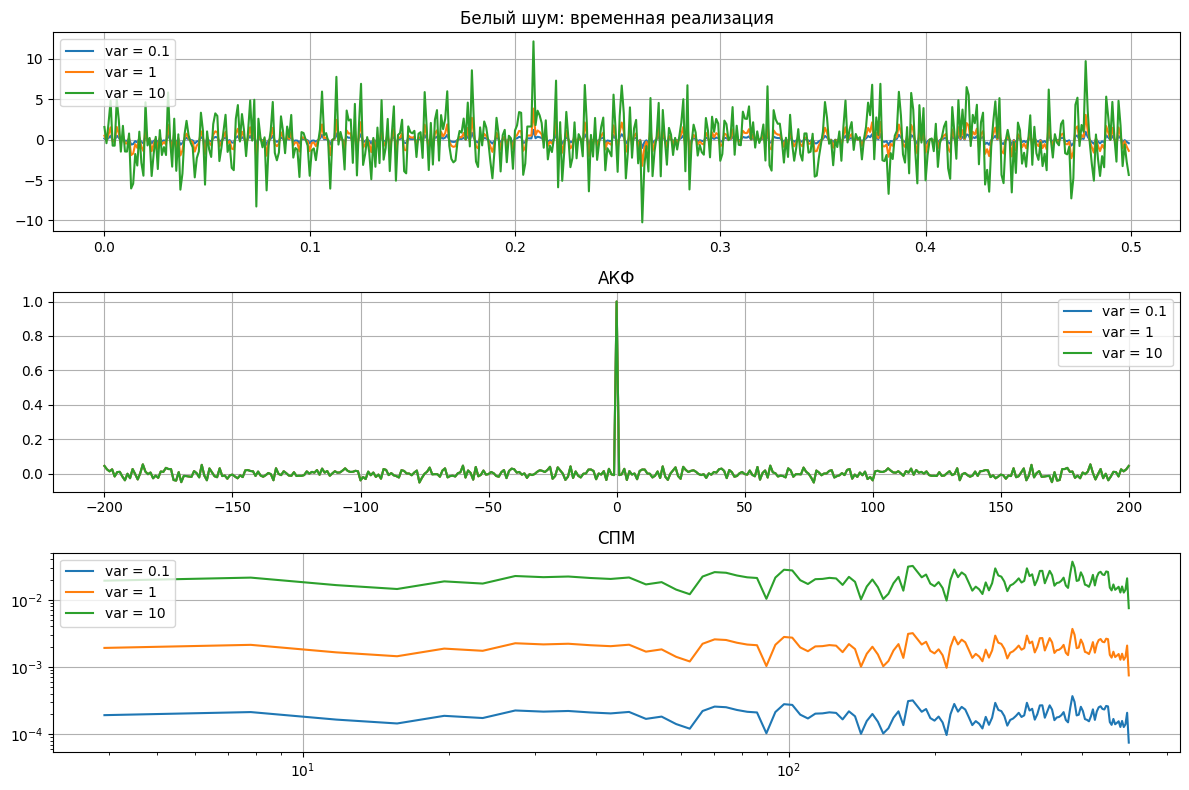

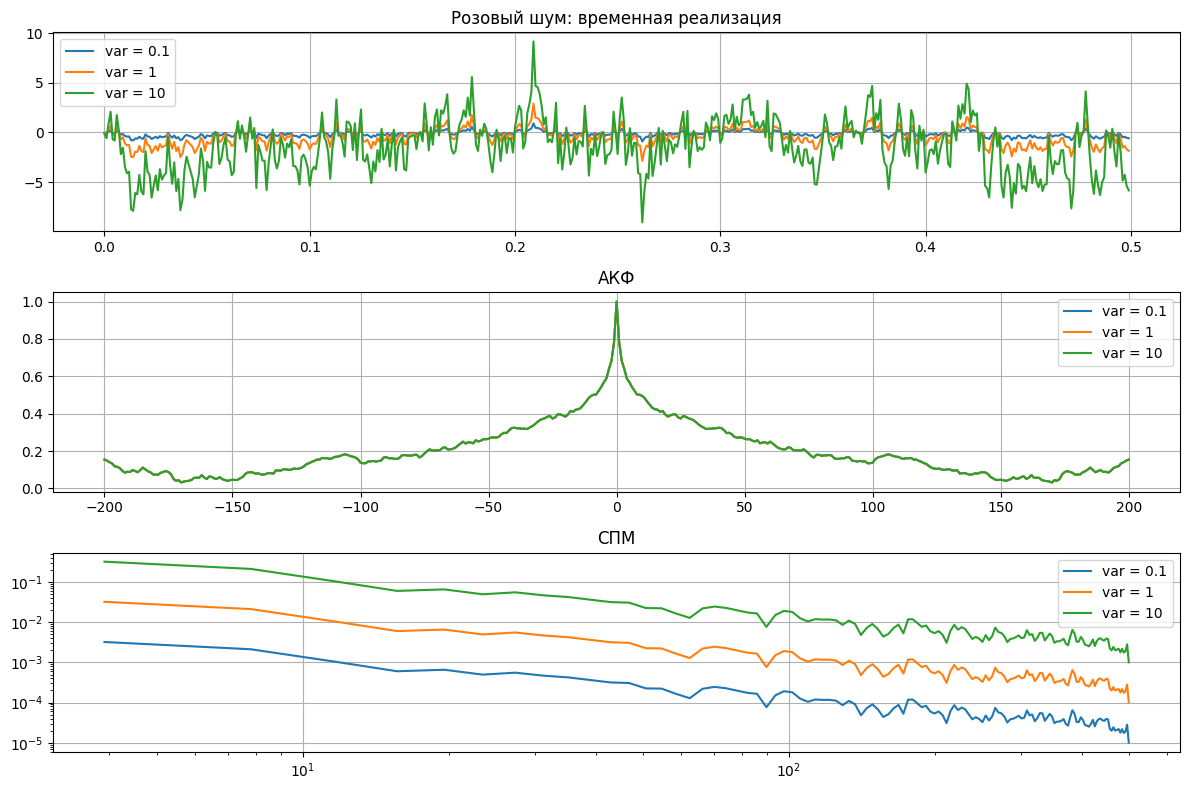

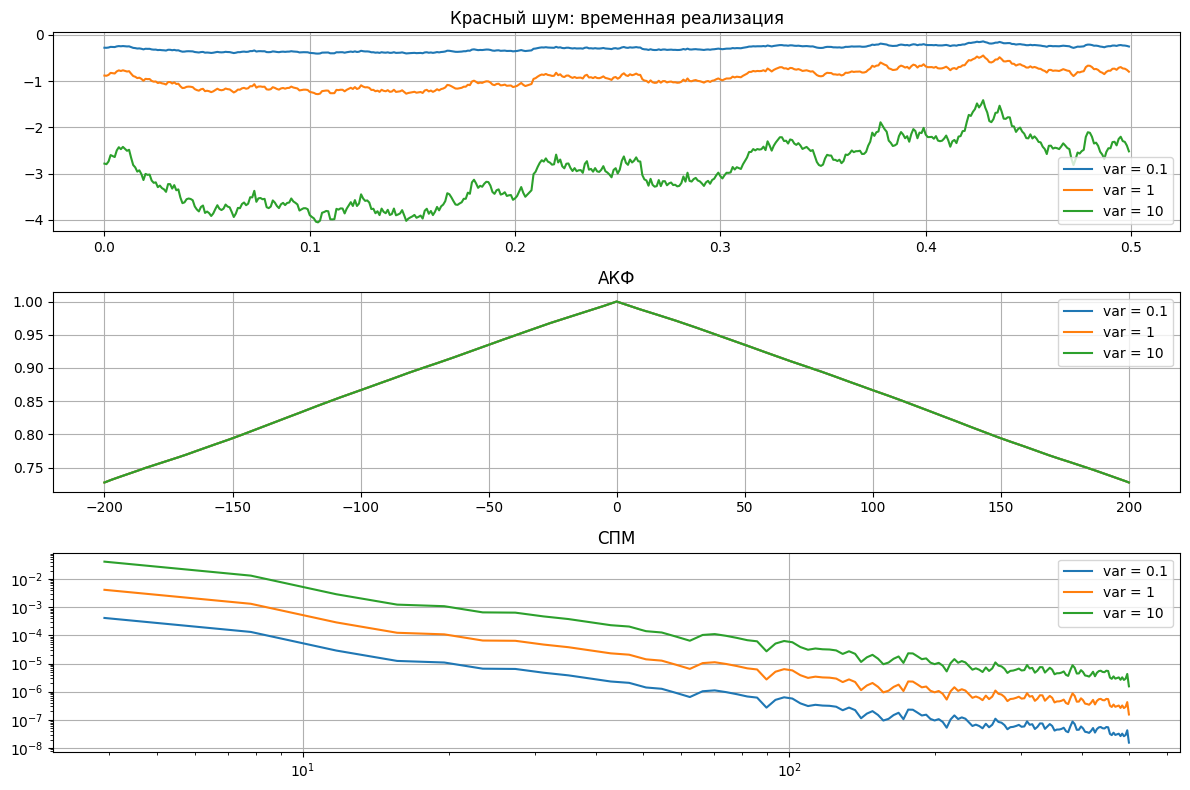

In [5]:
variances = [0.1, 1, 10]

for noise_name in ['Белый шум', 'Розовый шум', 'Красный шум']:
    plt.figure(figsize=(12, 8))

    for var in variances:
        np.random.seed(42)
        base_white = make_white(var=1.0)

        if noise_name == 'Белый шум':
            x = base_white * np.sqrt(var)
        elif noise_name == 'Розовый шум':
            x = make_pink_from_white(base_white, var=var)
        else:
            x = make_red_from_white(base_white, var=var)

        lags, acf = autocorr(x)
        f_welch, P_welch = signal.welch(x, fs, nperseg=256, noverlap=128, window='hann')

        plt.subplot(3, 1, 1)
        plt.plot(t[:500], x[:500], label=f'var = {var}')
        plt.title(f'{noise_name}: временная реализация')
        plt.grid(True)

        plt.subplot(3, 1, 2)
        center = len(acf) // 2
        plt.plot(lags[center-200:center+201], acf[center-200:center+201], label=f'var = {var}')
        plt.title('АКФ')
        plt.grid(True)

        plt.subplot(3, 1, 3)
        plt.loglog(f_welch[1:], P_welch[1:], label=f'var = {var}')
        plt.title('СПМ')
        plt.grid(True)

    plt.subplot(3, 1, 1)
    plt.legend()
    plt.subplot(3, 1, 2)
    plt.legend()
    plt.subplot(3, 1, 3)
    plt.legend()
    plt.tight_layout()
    plt.show()



**Вопрос:** Что меняется при изменении дисперсии в каждом случае?


Меняется в основном масштаб: растут разброс по амплитуде, значение АКФ в нуле и уровень СПМ. Форма АКФ после нормировки и характер зависимости СПМ от частоты почти не меняются


## Задание 6. Обнаружение гармонического сигнала на фоне шума. Спектральный анализ зашумлённой синусоиды
Сгенерируйте сигнал длительностью 2 секунды (fs=1000 Гц), состоящий из:
- синусоиды частотой 110 Гц с амплитудой 1,
- белого гауссова шума с дисперсией, обеспечивающей отношение сигнал/шум (SNR) = 10 дБ.

SNR (дБ) = $10 \log_{10}(P_{signal}/P_{noise})$.

1. Оцените СПМ с помощью метода Уэлча (выберите `nperseg` так, чтобы частота 110 Гц была хорошо разрешена). Определите частоту пика и сравните с истинной.
2. Повторите для других значений SNR ($0$ дБ, $-10$ дБ, $-20$ дБ и т. д.)


SNR = 10 дБ, peak = 109.375 Гц
SNR = 0 дБ, peak = 109.375 Гц
SNR = -10 дБ, peak = 109.375 Гц
SNR = -20 дБ, peak = 109.375 Гц


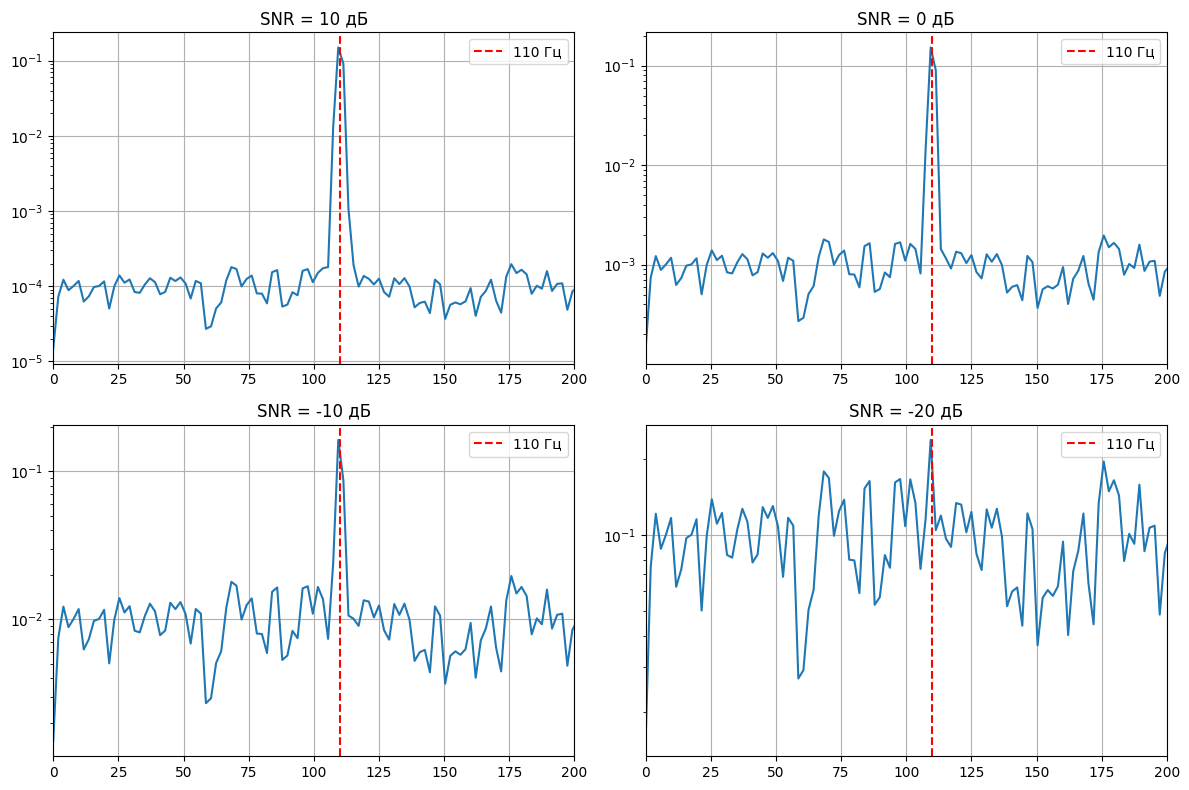

In [6]:
fs = 1000
t = np.arange(0, 2, 1 / fs)
signal_clean = np.sin(2 * np.pi * 110 * t)
P_signal = np.mean(signal_clean**2)

snr_values = [10, 0, -10, -20]

plt.figure(figsize=(12, 8))
for i, snr_db in enumerate(snr_values, start=1):
    snr_lin = 10**(snr_db / 10)
    P_noise = P_signal / snr_lin

    np.random.seed(42)
    noise = np.random.normal(0, np.sqrt(P_noise), len(t))
    x = signal_clean + noise

    f_welch, P_welch = signal.welch(x, fs, nperseg=512, noverlap=256, window='hann')
    peak_freq = f_welch[np.argmax(P_welch)]
    print(f'SNR = {snr_db} дБ, peak = {peak_freq:.3f} Гц')

    plt.subplot(2, 2, i)
    plt.semilogy(f_welch, P_welch)
    plt.axvline(110, color='r', linestyle='--', label='110 Гц')
    plt.title(f'SNR = {snr_db} дБ')
    plt.xlim(0, 200)
    plt.grid(True)
    plt.legend()

plt.tight_layout()
plt.show()



**Вопрос:** Как меняется видимость пика на спектре при изменении SNR? При каком SNR пик ещё можно уверенно обнаружить визуально?


1) При уменьшении SNR пик на 110 Гц становится ниже относительно шумового фона и хуже выделяется
2) До примерно -10 дБ его ещё можно уверенно заметить, а при -20 дБ это уже трудно


## Задание 7. Разрешение двух близких частот
Сгенерируйте сигнал, содержащий две синусоиды с частотами 100 и 110 Гц, равными амплитудами 1, и белый шум с дисперсией 0.1. Длительность сигнала 1 секунда, fs=1000 Гц. Используйте метод Уэлча с разными длинами сегмента: 128, 256, 512. Постройте оценки СПМ для каждого случая.


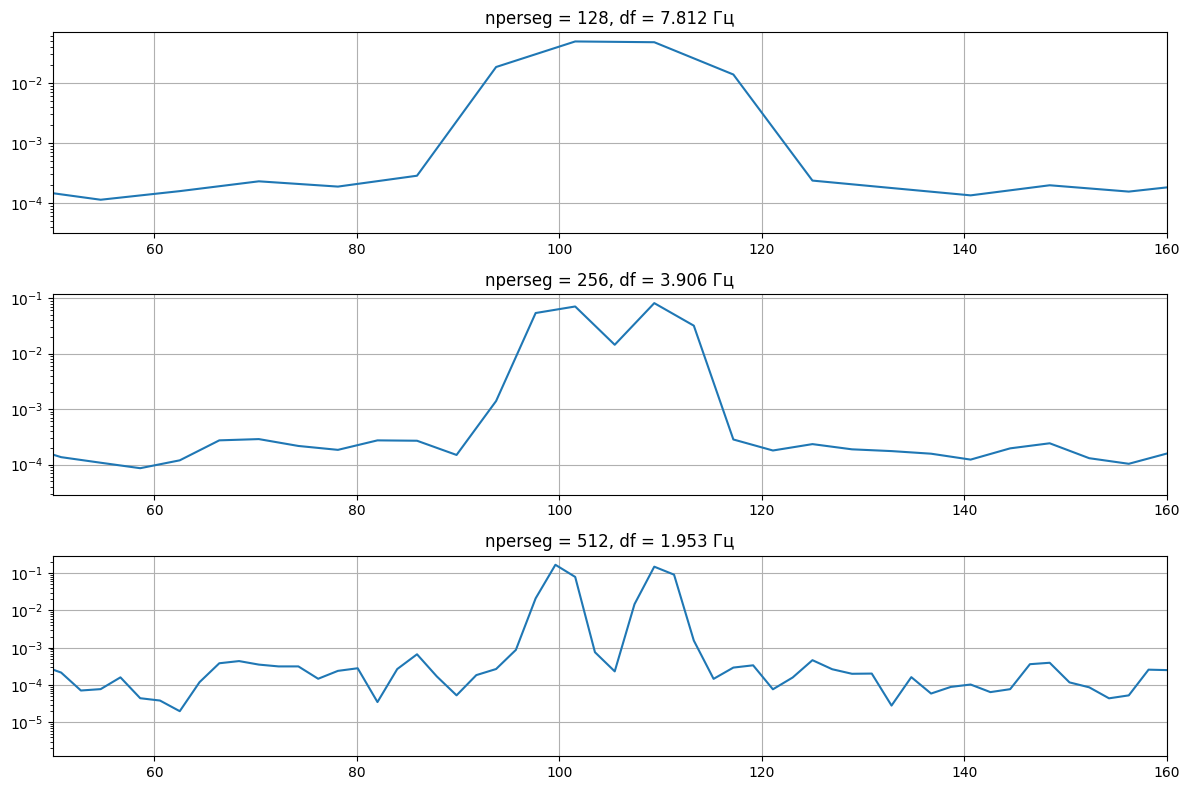

In [7]:
fs = 1000
t = np.arange(0, 1, 1 / fs)

np.random.seed(42)
x = (
    np.sin(2 * np.pi * 100 * t)
    + np.sin(2 * np.pi * 110 * t)
    + np.random.normal(0, np.sqrt(0.1), len(t))
)

nperseg_values = [128, 256, 512]

plt.figure(figsize=(12, 8))
for i, nperseg in enumerate(nperseg_values, start=1):
    f_welch, P_welch = signal.welch(x, fs, nperseg=nperseg, noverlap=nperseg // 2, window='hann')

    plt.subplot(3, 1, i)
    plt.semilogy(f_welch, P_welch)
    plt.title(f'nperseg = {nperseg}, df = {f_welch[1] - f_welch[0]:.3f} Гц')
    plt.xlim(50, 160)
    plt.grid(True)

plt.tight_layout()
plt.show()



**Вопрос:** При какой длине сегмента удаётся разделить две частоты? Сравните с грубой теоретической оценкой частотного разрешения $\Delta f \approx f_s / N_{seg}$.


1) При nperseg = 512 две частоты уже разделяются уверенно
2) При nperseg = 256 они только начинают намечаться, а при 128 сливаются
3) Это согласуется с оценкой df = fs / Nseg: примерно 7.8, 3.9 и 2.0 Гц соответственно при расстоянии между частотами 10 Гц
